# Construction Machinery Task Time Estimation
## CatBoost Regression Model

### Objective
Predict the actual completion time of construction machinery tasks
using historical task, machine, operator, environmental, and operational data.

### Target
`Actual_Time_min`

### Model
CatBoost Regressor

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
DATA_PATH = "X:\\Cat-hack\\catalyst\\ml\\datasets\\task_time_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2000, 27)


In [4]:
df.head()

,Task_ID,Task_Date,Machine_ID,Machine_Type,Machine_Age_yrs,Machine_Maintenance_Status,Operator_ID,Operator_Skill,Operator_Fatigue_Level,Task_Type,...,Weather,Temperature_C,Humidity_Percent,Visibility,Shift_Time,Estimated_Time_min,Breakdown_During_Task,Delay_Reason,Actual_Time_min,Time_Deviation_Percent
0,TASK00001,2025-01-22,MC1010,Excavator,10,Due Soon,OP1011,Intermediate,2.4,Demolition,...,Clear,28.9,55.8,Poor,Morning,74.0,No,NaN,143.6,94.05
1,TASK00002,2025-02-21,MC1001,Excavator,1,Due Soon,OP1001,Beginner,8.5,Demolition,...,Cloudy,30.5,79.7,Good,Night,123.4,No,NaN,220.8,78.93
2,TASK00003,2025-01-27,MC1010,Excavator,10,Good,OP1019,Expert,1.6,Earth Excavation,...,Clear,33.5,51.5,Good,Afternoon,164.1,No,Weather,223.0,35.89
3,TASK00004,2025-05-20,MC1007,Bulldozer,7,Due Soon,OP1012,Intermediate,4.8,Trenching,...,Cloudy,25.8,68.2,Moderate,Afternoon,187.6,No,NaN,246.0,31.13
4,TASK00005,2025-08-15,MC1003,Excavator,4,Due Soon,OP1009,Intermediate,5.4,Demolition,...,Cloudy,32.0,71.7,Good,Morning,139.2,No,NaN,197.7,42.03


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Task_ID                     2000 non-null   object 
 1   Task_Date                   2000 non-null   object 
 2   Machine_ID                  2000 non-null   object 
 3   Machine_Type                2000 non-null   object 
 4   Machine_Age_yrs             2000 non-null   int64  
 5   Machine_Maintenance_Status  2000 non-null   object 
 6   Operator_ID                 2000 non-null   object 
 7   Operator_Skill              2000 non-null   object 
 8   Operator_Fatigue_Level      1904 non-null   float64
 9   Task_Type                   2000 non-null   object 
 10  Task_Volume                 2000 non-null   float64
 11  Load_Weight_tons            1890 non-null   float64
 12  Travel_Distance_m           1899 non-null   float64
 13  Fuel_Consumption_L          1894 

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nTask Types:")
print(df["Task_Type"].value_counts())

print("\nMachine Types:")
print(df["Machine_Type"].value_counts())

print("\nOperator Skills:")
print(df["Operator_Skill"].value_counts())

Number of rows: 2000
Number of columns: 27

Task Types:
Task_Type
Earth Excavation    421
Material Loading    405
Trenching           404
Demolition          392
Grading             378
Name: count, dtype: int64

Machine Types:
Machine_Type
Excavator    745
Bulldozer    629
Loader       626
Name: count, dtype: int64

Operator Skills:
Operator_Skill
Intermediate    717
Expert          665
Beginner        618
Name: count, dtype: int64


In [7]:
print("\nMachine Ages:")
print(df.groupby("Machine_ID")["Machine_Age_yrs"].first())


Machine Ages:
Machine_ID
MC1001     1
MC1002     2
MC1003     4
MC1004     5
MC1005     6
MC1006     3
MC1007     7
MC1008     8
MC1009     9
MC1010    10
Name: Machine_Age_yrs, dtype: int64


In [8]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values:")
print(missing)

Missing values:
Delay_Reason                 1766
Temperature_C                 120
Load_Weight_tons              110
Site_Condition                110
Fuel_Consumption_L            106
Visibility                    105
Humidity_Percent              102
Travel_Distance_m             101
Operator_Fatigue_Level         96
Site_Terrain                   95
Idle_Time_during_task_min      90
Shift_Time                     88
dtype: int64


In [9]:
missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent[missing_percent > 0]

Delay_Reason                 88.30
Temperature_C                 6.00
Site_Condition                5.50
Load_Weight_tons              5.50
Fuel_Consumption_L            5.30
Visibility                    5.25
Humidity_Percent              5.10
Travel_Distance_m             5.05
Operator_Fatigue_Level        4.80
Site_Terrain                  4.75
Idle_Time_during_task_min     4.50
Shift_Time                    4.40
dtype: float64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate Task IDs:", df["Task_ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Task IDs: 0


In [11]:
TARGET = "Actual_Time_min"

In [12]:
df[TARGET].describe()

count    2000.000000
mean      262.707200
std       132.026501
min        53.900000
25%       170.325000
50%       236.500000
75%       319.650000
max      1009.000000
Name: Actual_Time_min, dtype: float64

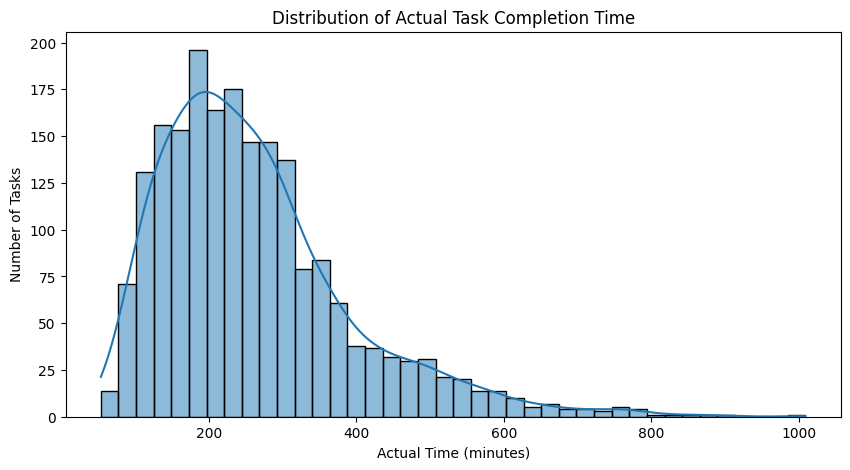

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df[TARGET],
    bins=40,
    kde=True
)

plt.title("Distribution of Actual Task Completion Time")
plt.xlabel("Actual Time (minutes)")
plt.ylabel("Number of Tasks")

plt.show()

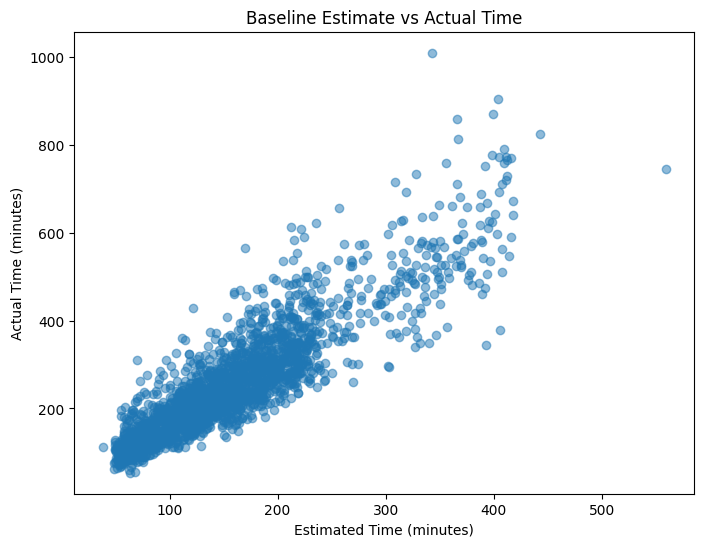

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Estimated_Time_min"],
    df["Actual_Time_min"],
    alpha=0.5
)

plt.xlabel("Estimated Time (minutes)")
plt.ylabel("Actual Time (minutes)")
plt.title("Baseline Estimate vs Actual Time")

plt.show()

In [15]:
baseline_pred = df["Estimated_Time_min"]

baseline_mae = mean_absolute_error(
    df["Actual_Time_min"],
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        df["Actual_Time_min"],
        baseline_pred
    )
)

baseline_r2 = r2_score(
    df["Actual_Time_min"],
    baseline_pred
)

print("=" * 45)
print("BASELINE MODEL: Estimated_Time_min")
print("=" * 45)

print(f"MAE  : {baseline_mae:.2f} minutes")
print(f"RMSE : {baseline_rmse:.2f} minutes")
print(f"R²   : {baseline_r2:.4f}")

BASELINE MODEL: Estimated_Time_min
MAE  : 102.50 minutes
RMSE : 125.17 minutes
R²   : 0.1008


In [16]:
TARGET = "Actual_Time_min"

features = [
    "Machine_Type",
    "Machine_Age_yrs",
    "Machine_Maintenance_Status",
    "Operator_Skill",
    "Operator_Fatigue_Level",
    "Task_Type",
    "Task_Volume",
    "Load_Weight_tons",
    "Travel_Distance_m",
    "Site_Terrain",
    "Site_Condition",
    "Weather",
    "Temperature_C",
    "Humidity_Percent",
    "Visibility",
    "Shift_Time",
    "Estimated_Time_min"
]

X = df[features].copy()
y = df[TARGET].copy()

print("Number of features:", len(features))
print("Samples:", len(X))

Number of features: 17
Samples: 2000


In [17]:
categorical_features = [
    "Machine_Type",
    "Machine_Maintenance_Status",
    "Operator_Skill",
    "Task_Type",
    "Site_Terrain",
    "Site_Condition",
    "Weather",
    "Visibility",
    "Shift_Time"
]

In [18]:
for col in categorical_features:
    X[col] = X[col].fillna("Unknown").astype(str)

In [19]:
numerical_features = [
    col for col in features
    if col not in categorical_features
]

for col in numerical_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1600
Testing samples: 400


In [21]:
model = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

In [22]:
model.fit(
    X_train,
    y_train,

    cat_features=categorical_features,

    eval_set=(X_test, y_test),

    early_stopping_rounds=100
)

0:	learn: 94.9132272	test: 98.3013946	best: 98.3013946 (0)	total: 198ms	remaining: 3m 17s
100:	learn: 28.9085665	test: 32.4536714	best: 32.4536714 (100)	total: 4.29s	remaining: 38.2s
200:	learn: 24.2459410	test: 29.8097682	best: 29.8097682 (200)	total: 8.15s	remaining: 32.4s
300:	learn: 21.7555122	test: 29.0262477	best: 28.9993753 (296)	total: 12s	remaining: 27.8s
400:	learn: 20.0405373	test: 28.5317907	best: 28.5279807 (398)	total: 15.8s	remaining: 23.7s
500:	learn: 18.7194649	test: 28.4802010	best: 28.4690282 (498)	total: 19.7s	remaining: 19.7s
600:	learn: 17.6163147	test: 28.3234398	best: 28.2914908 (577)	total: 23.3s	remaining: 15.5s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 28.29149083
bestIteration = 577

Shrink model to first 578 iterations.


CatBoostRegressor(depth=6, eval_metric='MAE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("=" * 45)
print("CATBOOST MODEL PERFORMANCE")
print("=" * 45)

print(f"MAE  : {mae:.2f} minutes")
print(f"RMSE : {rmse:.2f} minutes")
print(f"R²   : {r2:.4f}")

CATBOOST MODEL PERFORMANCE
MAE  : 28.29 minutes
RMSE : 39.29 minutes
R²   : 0.9195


## Feature Importance

Feature importance helps us understand which task, machine,
operator, and environmental variables contributed most to the
CatBoost predictions.

In [24]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

importance

,Feature,Importance
0,Estimated_Time_min,43.762438
1,Task_Volume,20.975877
2,Site_Terrain,6.884078
3,Operator_Skill,6.395024
4,Weather,2.991183
5,Site_Condition,2.970294
6,Machine_Maintenance_Status,2.348005
7,Machine_Age_yrs,1.749205
8,Operator_Fatigue_Level,1.663892
9,Load_Weight_tons,1.658107


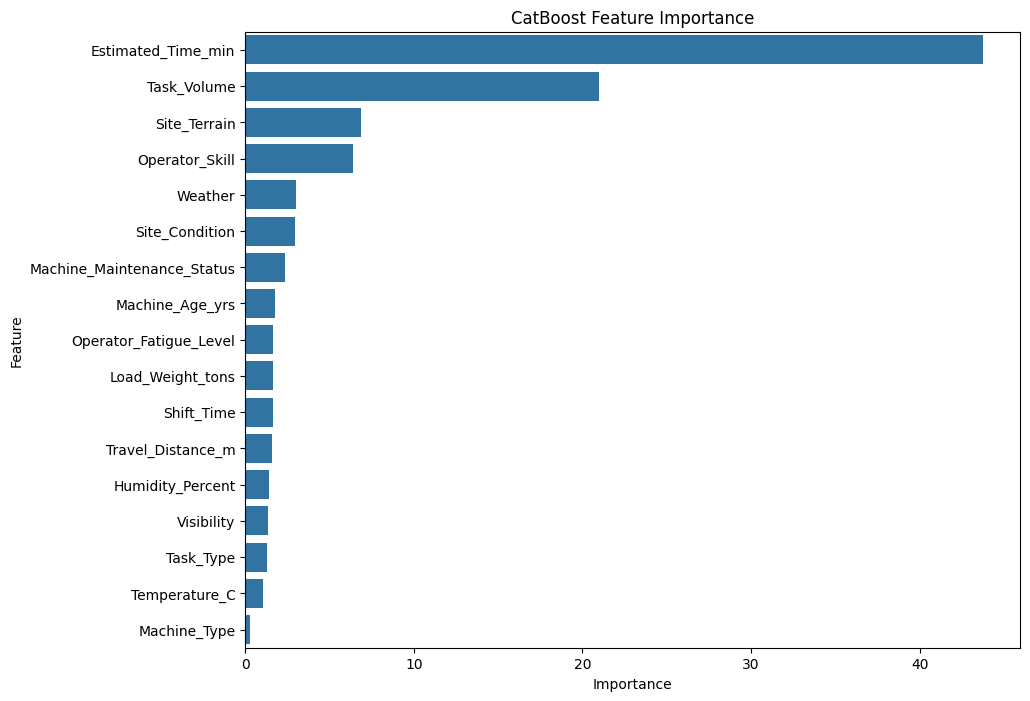

In [25]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

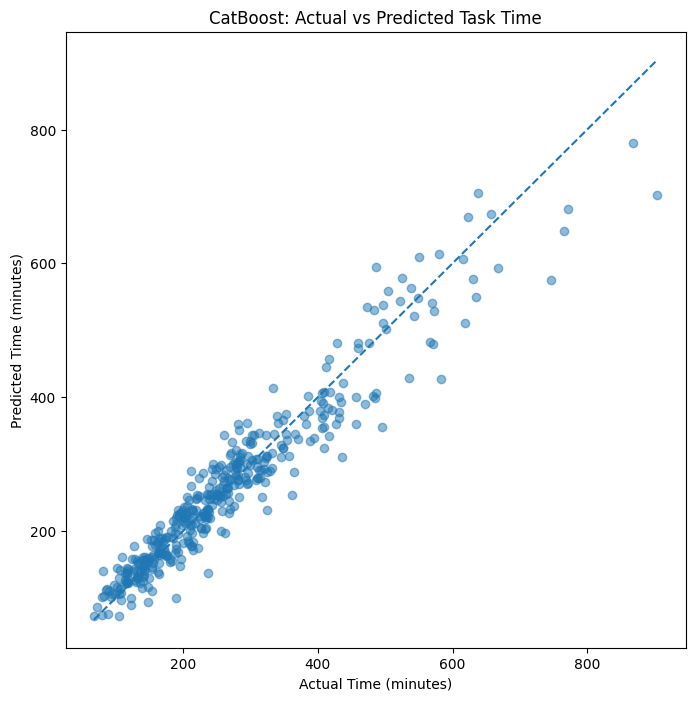

In [26]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Time (minutes)")
plt.ylabel("Predicted Time (minutes)")
plt.title("CatBoost: Actual vs Predicted Task Time")

plt.show()

In [27]:
residuals = y_test - y_pred

Residual Analysis

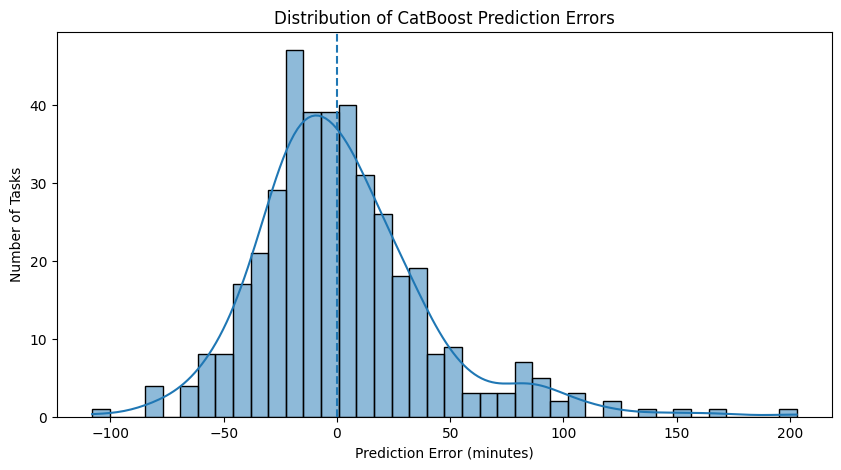

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (minutes)")
plt.ylabel("Number of Tasks")
plt.title("Distribution of CatBoost Prediction Errors")

plt.show()

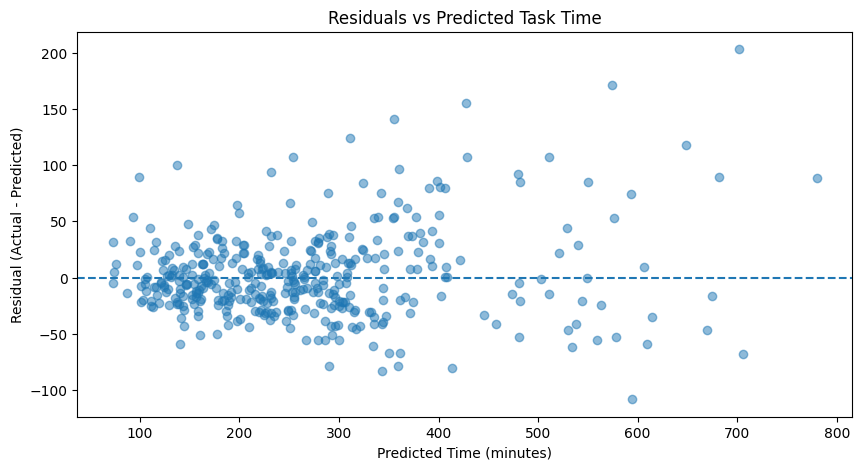

In [29]:
plt.figure(figsize=(10, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Time (minutes)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Task Time")

plt.show()

Feature Importance

In [30]:
sample_task = X_test.iloc[[0]].copy()

sample_task

,Machine_Type,Machine_Age_yrs,Machine_Maintenance_Status,Operator_Skill,Operator_Fatigue_Level,Task_Type,Task_Volume,Load_Weight_tons,Travel_Distance_m,Site_Terrain,Site_Condition,Weather,Temperature_C,Humidity_Percent,Visibility,Shift_Time,Estimated_Time_min
1860,Loader,5,Due Soon,Beginner,4.6,Material Loading,537.1,7.89,379.4,Flat,Muddy,Clear,36.7,64.6,Good,Night,214.1


In [31]:
expert_task = sample_task.copy()
beginner_task = sample_task.copy()

expert_task["Operator_Skill"] = "Expert"
beginner_task["Operator_Skill"] = "Beginner"

expert_prediction = model.predict(expert_task)[0]
beginner_prediction = model.predict(beginner_task)[0]

print("Expert prediction:", round(expert_prediction, 2))
print("Beginner prediction:", round(beginner_prediction, 2))

Expert prediction: 337.58
Beginner prediction: 401.74


In [32]:
clear_task = sample_task.copy()
rainy_task = sample_task.copy()

clear_task["Weather"] = "Clear"
rainy_task["Weather"] = "Rainy"

clear_prediction = model.predict(clear_task)[0]
rainy_prediction = model.predict(rainy_task)[0]

print("Clear:", round(clear_prediction, 2))
print("Rainy:", round(rainy_prediction, 2))

Clear: 401.74
Rainy: 427.75


In [33]:
flat_task = sample_task.copy()
rocky_task = sample_task.copy()

flat_task["Site_Terrain"] = "Flat"
rocky_task["Site_Terrain"] = "Rocky"

flat_prediction = model.predict(flat_task)[0]
rocky_prediction = model.predict(rocky_task)[0]

print("Flat:", round(flat_prediction, 2))
print("Rocky:", round(rocky_prediction, 2))

Flat: 401.74
Rocky: 452.5


In [34]:
new_machine = sample_task.copy()
old_machine = sample_task.copy()

new_machine["Machine_Age_yrs"] = 2
old_machine["Machine_Age_yrs"] = 9

new_prediction = model.predict(new_machine)[0]
old_prediction = model.predict(old_machine)[0]

print("2-year machine:", round(new_prediction, 2))
print("9-year machine:", round(old_prediction, 2))

2-year machine: 394.37
9-year machine: 417.82


Evaluate performance by task type

In [35]:
# Add predictions to the test set
results = X_test.copy()
results["Actual_Time_min"] = y_test.values
results["Predicted_Time_min"] = y_pred

# Calculate absolute error
results["Absolute_Error_min"] = (
    results["Actual_Time_min"] - results["Predicted_Time_min"]
).abs()

# Performance by task type
task_performance = (
    results
    .groupby("Task_Type")
    .agg(
        Tasks=("Actual_Time_min", "count"),
        MAE=("Absolute_Error_min", "mean"),
        Actual_Mean=("Actual_Time_min", "mean"),
        Predicted_Mean=("Predicted_Time_min", "mean")
    )
    .round(2)
    .sort_values("MAE")
)

task_performance

,Tasks,MAE,Actual_Mean,Predicted_Mean
Task_Type,,,,
Demolition,83,23.41,201.39,200.51
Trenching,76,23.45,226.32,226.66
Earth Excavation,87,24.67,239.03,236.79
Material Loading,83,27.34,261.18,256.64
Grading,71,44.73,434.37,429.37


Calculate MAE by task type

In [36]:
for task in results["Task_Type"].unique():
    
    task_data = results[
        results["Task_Type"] == task
    ]
    
    task_mae = mean_absolute_error(
        task_data["Actual_Time_min"],
        task_data["Predicted_Time_min"]
    )
    
    task_rmse = np.sqrt(
        mean_squared_error(
            task_data["Actual_Time_min"],
            task_data["Predicted_Time_min"]
        )
    )
    
    task_r2 = r2_score(
        task_data["Actual_Time_min"],
        task_data["Predicted_Time_min"]
    )
    
    print(f"\n{task}")
    print(f"  MAE  : {task_mae:.2f} min")
    print(f"  RMSE : {task_rmse:.2f} min")
    print(f"  R²   : {task_r2:.4f}")


Material Loading
  MAE  : 27.34 min
  RMSE : 35.79 min
  R²   : 0.8909

Earth Excavation
  MAE  : 24.67 min
  RMSE : 35.77 min
  R²   : 0.8947

Grading
  MAE  : 44.73 min
  RMSE : 59.63 min
  R²   : 0.8836

Trenching
  MAE  : 23.45 min
  RMSE : 31.69 min
  R²   : 0.8563

Demolition
  MAE  : 23.41 min
  RMSE : 29.28 min
  R²   : 0.8196


Worst Predictions

In [37]:
worst_predictions = (
    results[
        [
            "Task_Type",
            "Actual_Time_min",
            "Predicted_Time_min",
            "Absolute_Error_min",
            "Estimated_Time_min",
            "Operator_Skill",
            "Site_Terrain",
            "Weather"
        ]
    ]
    .sort_values("Absolute_Error_min", ascending=False)
    .head(10)
)

worst_predictions

,Task_Type,Actual_Time_min,Predicted_Time_min,Absolute_Error_min,Estimated_Time_min,Operator_Skill,Site_Terrain,Weather
1541,Grading,904.4,701.448467,202.951533,404.5,Beginner,Steep,Windy
579,Grading,745.7,574.463586,171.236414,559.8,Intermediate,Rocky,Clear
637,Earth Excavation,582.2,427.223856,154.976144,215.4,Beginner,Rocky,Clear
1423,Material Loading,495.6,354.969715,140.630285,195.8,Beginner,Muddy,Cloudy
1394,Grading,435.7,311.267373,124.432627,229.7,Expert,Flat,Clear
1333,Grading,766.1,648.553208,117.546792,412.7,Expert,Muddy,Clear
1395,Grading,486.0,594.093612,108.093612,386.6,Intermediate,Rocky,Clear
63,Earth Excavation,536.1,428.653358,107.446642,205.0,Beginner,Rocky,Cloudy
1491,Earth Excavation,361.1,253.952171,107.147829,111.9,Beginner,Muddy,Rainy
266,Grading,618.1,511.067317,107.032683,387.7,Expert,Muddy,Clear


Check error by operator skill

In [38]:
skill_performance = (
    results
    .groupby("Operator_Skill")
    .agg(
        Tasks=("Actual_Time_min", "count"),
        MAE=("Absolute_Error_min", "mean"),
        Actual_Mean=("Actual_Time_min", "mean"),
        Predicted_Mean=("Predicted_Time_min", "mean")
    )
    .round(2)
)

skill_performance

,Tasks,MAE,Actual_Mean,Predicted_Mean
Operator_Skill,,,,
Beginner,128,33.45,300.74,290.07
Expert,130,27.44,248.10,255.27
Intermediate,142,24.42,256.92,253.11


Hyperparameter Tuning

In [39]:
from sklearn.model_selection import train_test_split

X_train_tune, X_val, y_train_tune, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train_tune.shape)
print("Validation:", X_val.shape)

Training: (1280, 17)
Validation: (320, 17)


In [40]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

configs = [
    {
        "name": "Model_1",
        "depth": 5,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    {
        "name": "Model_2",
        "depth": 6,
        "learning_rate": 0.05,
        "l2_leaf_reg": 3
    },
    {
        "name": "Model_3",
        "depth": 7,
        "learning_rate": 0.05,
        "l2_leaf_reg": 5
    },
    {
        "name": "Model_4",
        "depth": 8,
        "learning_rate": 0.05,
        "l2_leaf_reg": 5
    },
    {
        "name": "Model_5",
        "depth": 6,
        "learning_rate": 0.03,
        "l2_leaf_reg": 5
    },
    {
        "name": "Model_6",
        "depth": 6,
        "learning_rate": 0.10,
        "l2_leaf_reg": 5
    }
]

tuning_results = []

for config in configs:

    model_tune = CatBoostRegressor(
        iterations=1500,
        depth=config["depth"],
        learning_rate=config["learning_rate"],
        l2_leaf_reg=config["l2_leaf_reg"],
        loss_function="RMSE",
        eval_metric="MAE",
        random_seed=42,
        verbose=False
    )

    model_tune.fit(
        X_train_tune,
        y_train_tune,
        cat_features=categorical_features,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        verbose=False
    )

    val_pred = model_tune.predict(X_val)

    mae = mean_absolute_error(y_val, val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    r2 = r2_score(y_val, val_pred)

    tuning_results.append({
        "Model": config["name"],
        "Depth": config["depth"],
        "Learning_Rate": config["learning_rate"],
        "L2_Leaf_Reg": config["l2_leaf_reg"],
        "Best_Iteration": model_tune.get_best_iteration(),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df.sort_values("MAE")

,Model,Depth,Learning_Rate,L2_Leaf_Reg,Best_Iteration,MAE,RMSE,R2
4,Model_5,6,0.03,5,1458,28.361239,42.363119,0.881441
0,Model_1,5,0.05,3,789,28.551419,42.943360,0.878171
1,Model_2,6,0.05,3,707,28.647958,42.697281,0.879564
3,Model_4,8,0.05,5,700,29.162929,43.346862,0.875871
5,Model_6,6,0.10,5,488,29.172740,43.455949,0.875246
2,Model_3,7,0.05,5,951,29.326888,42.967828,0.878032


In [41]:
final_model = CatBoostRegressor(
    iterations=1500,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100
)

final_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=100
)

0:	learn: 96.4200315	test: 99.8482281	best: 99.8482281 (0)	total: 29.4ms	remaining: 44s
100:	learn: 35.1547202	test: 37.8917831	best: 37.8917831 (100)	total: 3.46s	remaining: 47.9s
200:	learn: 28.1712978	test: 31.5104787	best: 31.5104787 (200)	total: 7s	remaining: 45.3s
300:	learn: 25.7501054	test: 30.1566579	best: 30.1566579 (300)	total: 10.4s	remaining: 41.5s
400:	learn: 24.1383063	test: 29.6254169	best: 29.6243627 (398)	total: 14s	remaining: 38.4s
500:	learn: 22.8925609	test: 29.1796150	best: 29.1796150 (500)	total: 17.7s	remaining: 35.3s
600:	learn: 21.7401895	test: 28.8466965	best: 28.8466965 (600)	total: 21.3s	remaining: 31.9s
700:	learn: 20.8957139	test: 28.5161276	best: 28.5122491 (698)	total: 24.9s	remaining: 28.4s
800:	learn: 20.0580278	test: 28.3242016	best: 28.3242016 (800)	total: 28.7s	remaining: 25s
900:	learn: 19.3325993	test: 28.1246293	best: 28.1246293 (900)	total: 32.3s	remaining: 21.5s
1000:	learn: 18.6477438	test: 27.9833551	best: 27.9833551 (1000)	total: 36s	remain

CatBoostRegressor(depth=6, eval_metric='MAE', iterations=1500, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [42]:
final_pred = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print("=" * 50)
print("FINAL CATBOOST MODEL")
print("=" * 50)
print(f"MAE  : {final_mae:.2f} minutes")
print(f"RMSE : {final_rmse:.2f} minutes")
print(f"R²   : {final_r2:.4f}")

FINAL CATBOOST MODEL
MAE  : 27.87 minutes
RMSE : 39.10 minutes
R²   : 0.9203


In [45]:
import joblib
import os

# Package the trained model and the information needed for inference
model_package = {
    "model": final_model,
    "features": features,
    "categorical_features": categorical_features,
    "target": TARGET
}

# Windows path
model_path = r"X:\Cat-hack\catalyst\ml\models\task_time_.pkl"

# Save
joblib.dump(model_package, model_path)

# Verify
print("Model saved successfully!")
print("Path:", model_path)
print("Exists:", os.path.exists(model_path))
print("Size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

Model saved successfully!
Path: X:\Cat-hack\catalyst\ml\models\task_time_.pkl
Exists: True
Size: 1.62 MB
